# 00 — Load one WESAD subject

Smoke test for the WESAD dataset. Loads subject S2, confirms structure, verifies sampling rates via shape arithmetic (not docs alone), and saves 10-second sample plots of each chest modality.

**Reference**: Schmidt et al., [_Introducing WESAD, a Multimodal Dataset for Wearable Stress and Affect Detection_](https://dl.acm.org/doi/pdf/10.1145/3242969.3242985), ICMI 2018. Schema contract: [`docs/SCHEMA.md`](../docs/SCHEMA.md).


In [1]:
%config InlineBackend.figure_format = 'retina'
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wesad_stress.data import DATA_ROOT, VALID_SUBJECTS, load_wesad

## Load S2

`load_wesad()` reads the pickle file and returns the raw structure documented in [`docs/SCHEMA.md`](../docs/SCHEMA.md). The Python-2-era encoding quirk is handled inside the loader.


In [2]:
SUBJECT_ID = 2
pkl_path = DATA_ROOT / f"S{SUBJECT_ID}" / f"S{SUBJECT_ID}.pkl"
print(f"Loading: {pkl_path}")
print(f"File size: {pkl_path.stat().st_size / 1e6:.1f} MB")

data = load_wesad(SUBJECT_ID)

print(f"Top-level keys: {list(data.keys())}")
print(f"Subject:        {data['subject']}")
print(f"Signal keys:    {list(data['signal'].keys())}")
print(f"Chest modalities: {list(data['signal']['chest'].keys())}")
print(f"Wrist modalities: {list(data['signal']['wrist'].keys())}")

Loading: /Users/bkowshik/code/bkowshik/wesad-stress/data/raw/WESAD/S2/S2.pkl
File size: 975.1 MB
Top-level keys: ['signal', 'label', 'subject']
Subject:        S2
Signal keys:    ['chest', 'wrist']
Chest modalities: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Wrist modalities: ['ACC', 'BVP', 'EDA', 'TEMP']


## Shape, dtype, raw range per modality

The dict above carries the documented sampling rates from the Empatica E4 datasheet. The summary frame below compares them against the measured rate, computed from `len(signal) / duration_seconds`. Documentation is the hypothesis; shape arithmetic is the check. If the two columns disagree, the measured value wins.


In [3]:
CHEST_FS_NOMINAL = 700  # Hz, per Schmidt et al. — verify below
WRIST_FS_NOMINAL = {"ACC": 32, "BVP": 64, "EDA": 4, "TEMP": 4}

# Use any chest signal to ground session duration (all sampled at 700 Hz)
chest_len = len(data["signal"]["chest"]["ECG"])
duration_s = chest_len / CHEST_FS_NOMINAL
print(f"Session duration (from chest @ 700 Hz): {duration_s:.1f} s  ({duration_s/60:.1f} min)\n")

def summarise(modality, arr, nominal_fs):
    n = arr.shape[0]
    measured_fs = n / duration_s
    channels = arr.shape[1] if arr.ndim > 1 else 1
    return {
        "modality": modality,
        "shape": str(arr.shape),
        "dtype": str(arr.dtype),
        "channels": channels,
        "nominal_fs": nominal_fs,
        "measured_fs": round(measured_fs, 2),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
    }

rows = []
for m, arr in data["signal"]["chest"].items():
    rows.append({"device": "chest", **summarise(m, arr, CHEST_FS_NOMINAL)})
for m, arr in data["signal"]["wrist"].items():
    rows.append({"device": "wrist", **summarise(m, arr, WRIST_FS_NOMINAL.get(m, None))})

summary = pd.DataFrame(rows)
summary

Session duration (from chest @ 700 Hz): 6079.0 s  (101.3 min)



,device,modality,shape,dtype,channels,nominal_fs,measured_fs,min,max
0,chest,ACC,"(4255300, 3)",float64,3,700,700.0,-1.135400,2.029800
1,chest,ECG,"(4255300, 1)",float64,1,700,700.0,-1.499542,1.499313
2,chest,EMG,"(4255300, 1)",float64,1,700,700.0,-0.414963,0.300980
3,chest,EDA,"(4255300, 1)",float64,1,700,700.0,0.263214,7.576752
4,chest,Temp,"(4255300, 1)",float32,1,700,700.0,28.045258,34.370392
5,chest,Resp,"(4255300, 1)",float64,1,700,700.0,-27.903748,27.378845
6,wrist,ACC,"(194528, 3)",float64,3,32,32.0,-128.000000,127.000000
7,wrist,BVP,"(389056, 1)",float64,1,64,64.0,-873.670000,988.080000
8,wrist,EDA,"(24316, 1)",float64,1,4,4.0,0.045113,1.717419
9,wrist,TEMP,"(24316, 1)",float64,1,4,4.0,32.310000,35.970000


## Label distribution

Labels are sampled at the chest rate (700 Hz). Canonical 3-class problem uses {1: baseline, 2: stress, 3: amusement}; {0, 5, 6, 7} are ignore/transient/recovery.


In [4]:
LABEL_NAMES = {
    0: "not defined / transient",
    1: "baseline",
    2: "stress",
    3: "amusement",
    4: "meditation",
    5: "ignore (5)",
    6: "ignore (6)",
    7: "ignore (7)",
}

labels = data["label"]
label_fs = len(labels) / duration_s
print(f"Label array shape: {labels.shape}, dtype: {labels.dtype}")
print(f"Label sampling rate (measured): {label_fs:.2f} Hz\n")

vals, counts = np.unique(labels, return_counts=True)
label_df = pd.DataFrame({
    "label": vals,
    "name": [LABEL_NAMES.get(v, "unknown") for v in vals],
    "samples": counts,
    "seconds": (counts / label_fs).round(1),
    "pct": (counts / counts.sum() * 100).round(2),
})
label_df

Label array shape: (4255300,), dtype: int32
Label sampling rate (measured): 700.00 Hz



,label,name,samples,seconds,pct
0,0,not defined / transient,2142701,3061.0,50.35
1,1,baseline,800800,1144.0,18.82
2,2,stress,430500,615.0,10.12
3,3,amusement,253400,362.0,5.95
4,4,meditation,537599,768.0,12.63
5,6,ignore (6),45500,65.0,1.07
6,7,ignore (7),44800,64.0,1.05


## 10-second sample plots — chest modalities

A small window from the baseline period (label == 1) for each chest signal. Sanity check that loading + scaling looks right — not analysis.


Window: samples [214583, 221583) — 10s of baseline starting at t=306.5s
Saved: /Users/bkowshik/code/bkowshik/wesad-stress/images/2026-05-28-s2-chest-10s-baseline.png


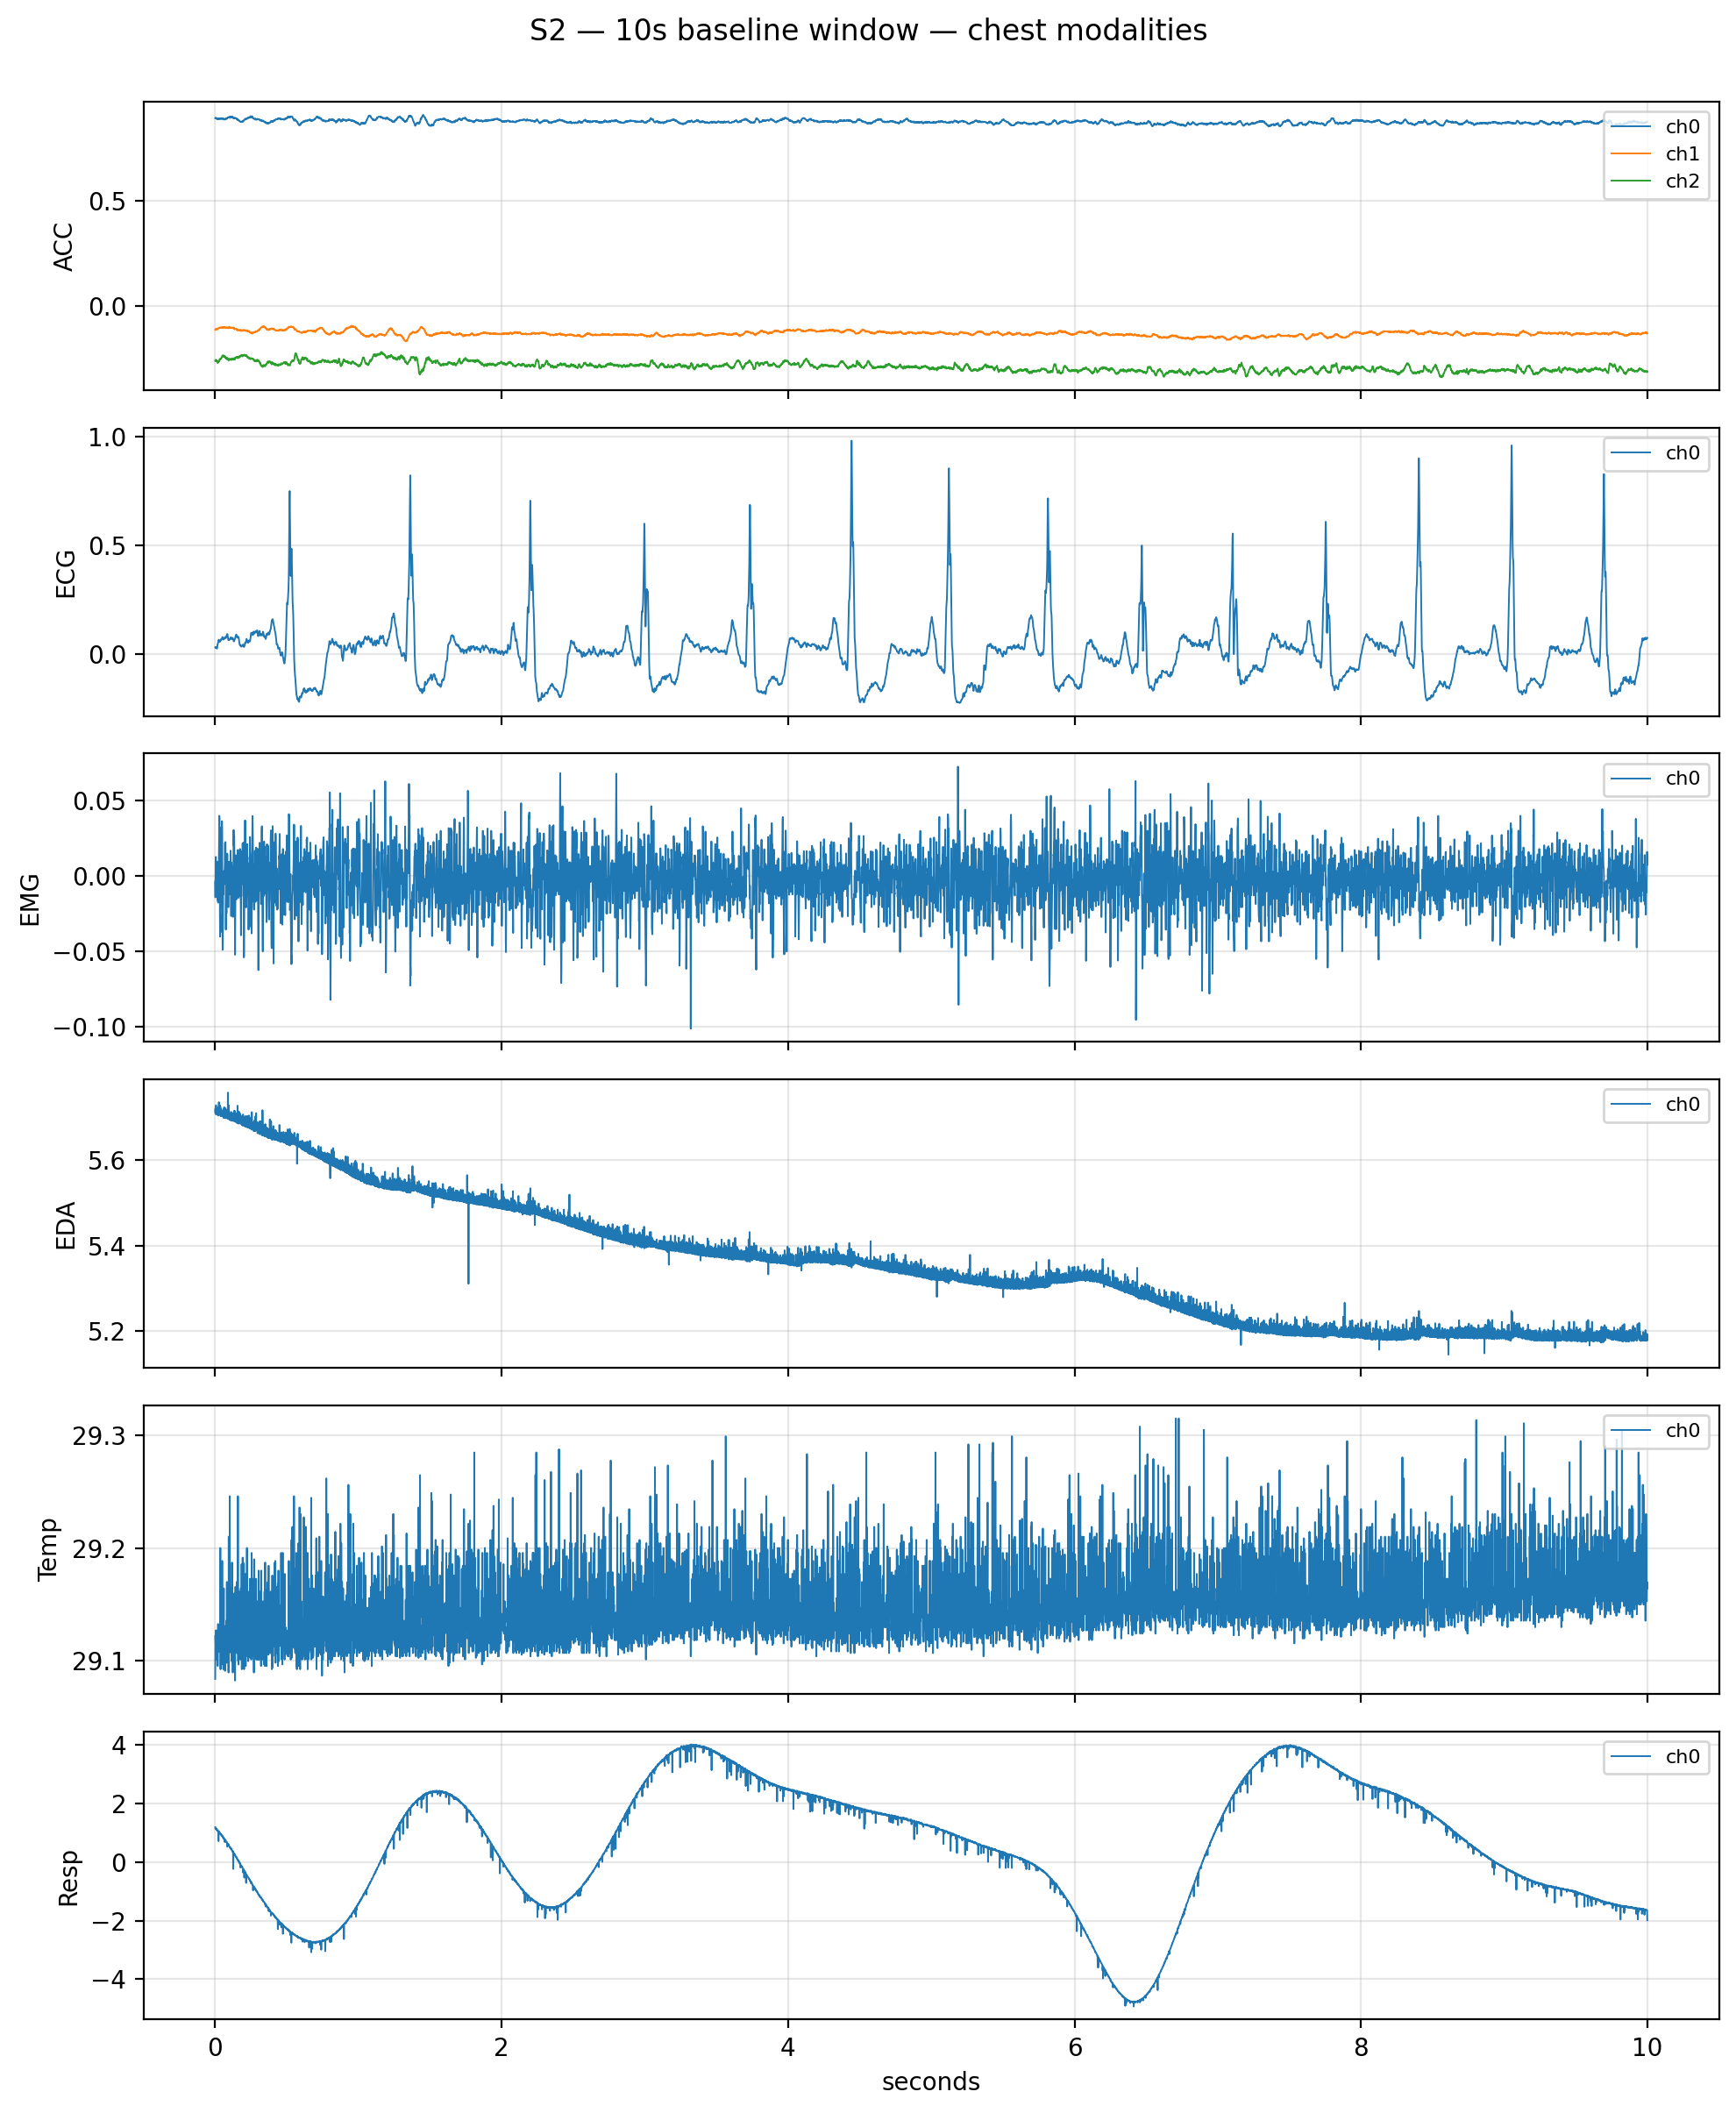

In [5]:
# Find the first baseline (label==1) window of 10s, in chest-rate samples
WINDOW_S = 10
WINDOW_N = WINDOW_S * CHEST_FS_NOMINAL

baseline_idx = np.where(labels == 1)[0]
start = int(baseline_idx[0])
end = start + WINDOW_N
print(f"Window: samples [{start}, {end}) — {WINDOW_S}s of baseline starting at t={start/CHEST_FS_NOMINAL:.1f}s")

t = np.arange(WINDOW_N) / CHEST_FS_NOMINAL
chest = data["signal"]["chest"]

fig, axes = plt.subplots(len(chest), 1, figsize=(10, 2 * len(chest)), sharex=True)
for ax, (m, arr) in zip(axes, chest.items()):
    window = arr[start:end]
    if window.ndim > 1:
        for ch in range(window.shape[1]):
            ax.plot(t, window[:, ch], lw=0.7, label=f"ch{ch}")
        ax.legend(loc="upper right", fontsize=8)
    else:
        ax.plot(t, window, lw=0.7)
    ax.set_ylabel(m)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("seconds")
fig.suptitle(f"S{SUBJECT_ID} — 10s baseline window — chest modalities", y=1.0)
fig.tight_layout()

out_path = Path("../images/2026-05-28-s2-chest-10s-baseline.png")
out_path.parent.mkdir(exist_ok=True)
fig.savefig(out_path, dpi=110, bbox_inches="tight")
print(f"Saved: {out_path.resolve()}")
plt.show()

## 10-second sample plots — wrist modalities

Same baseline window as the chest plot above, sampled at each wrist modality's own rate. The 4 Hz signals (EDA, TEMP) look noticeably coarser than the 32 Hz ACC and 64 Hz BVP — that resolution asymmetry is real, not a rendering artefact.


Saved: /Users/bkowshik/code/bkowshik/wesad-stress/images/2026-05-28-s2-wrist-10s-baseline.png


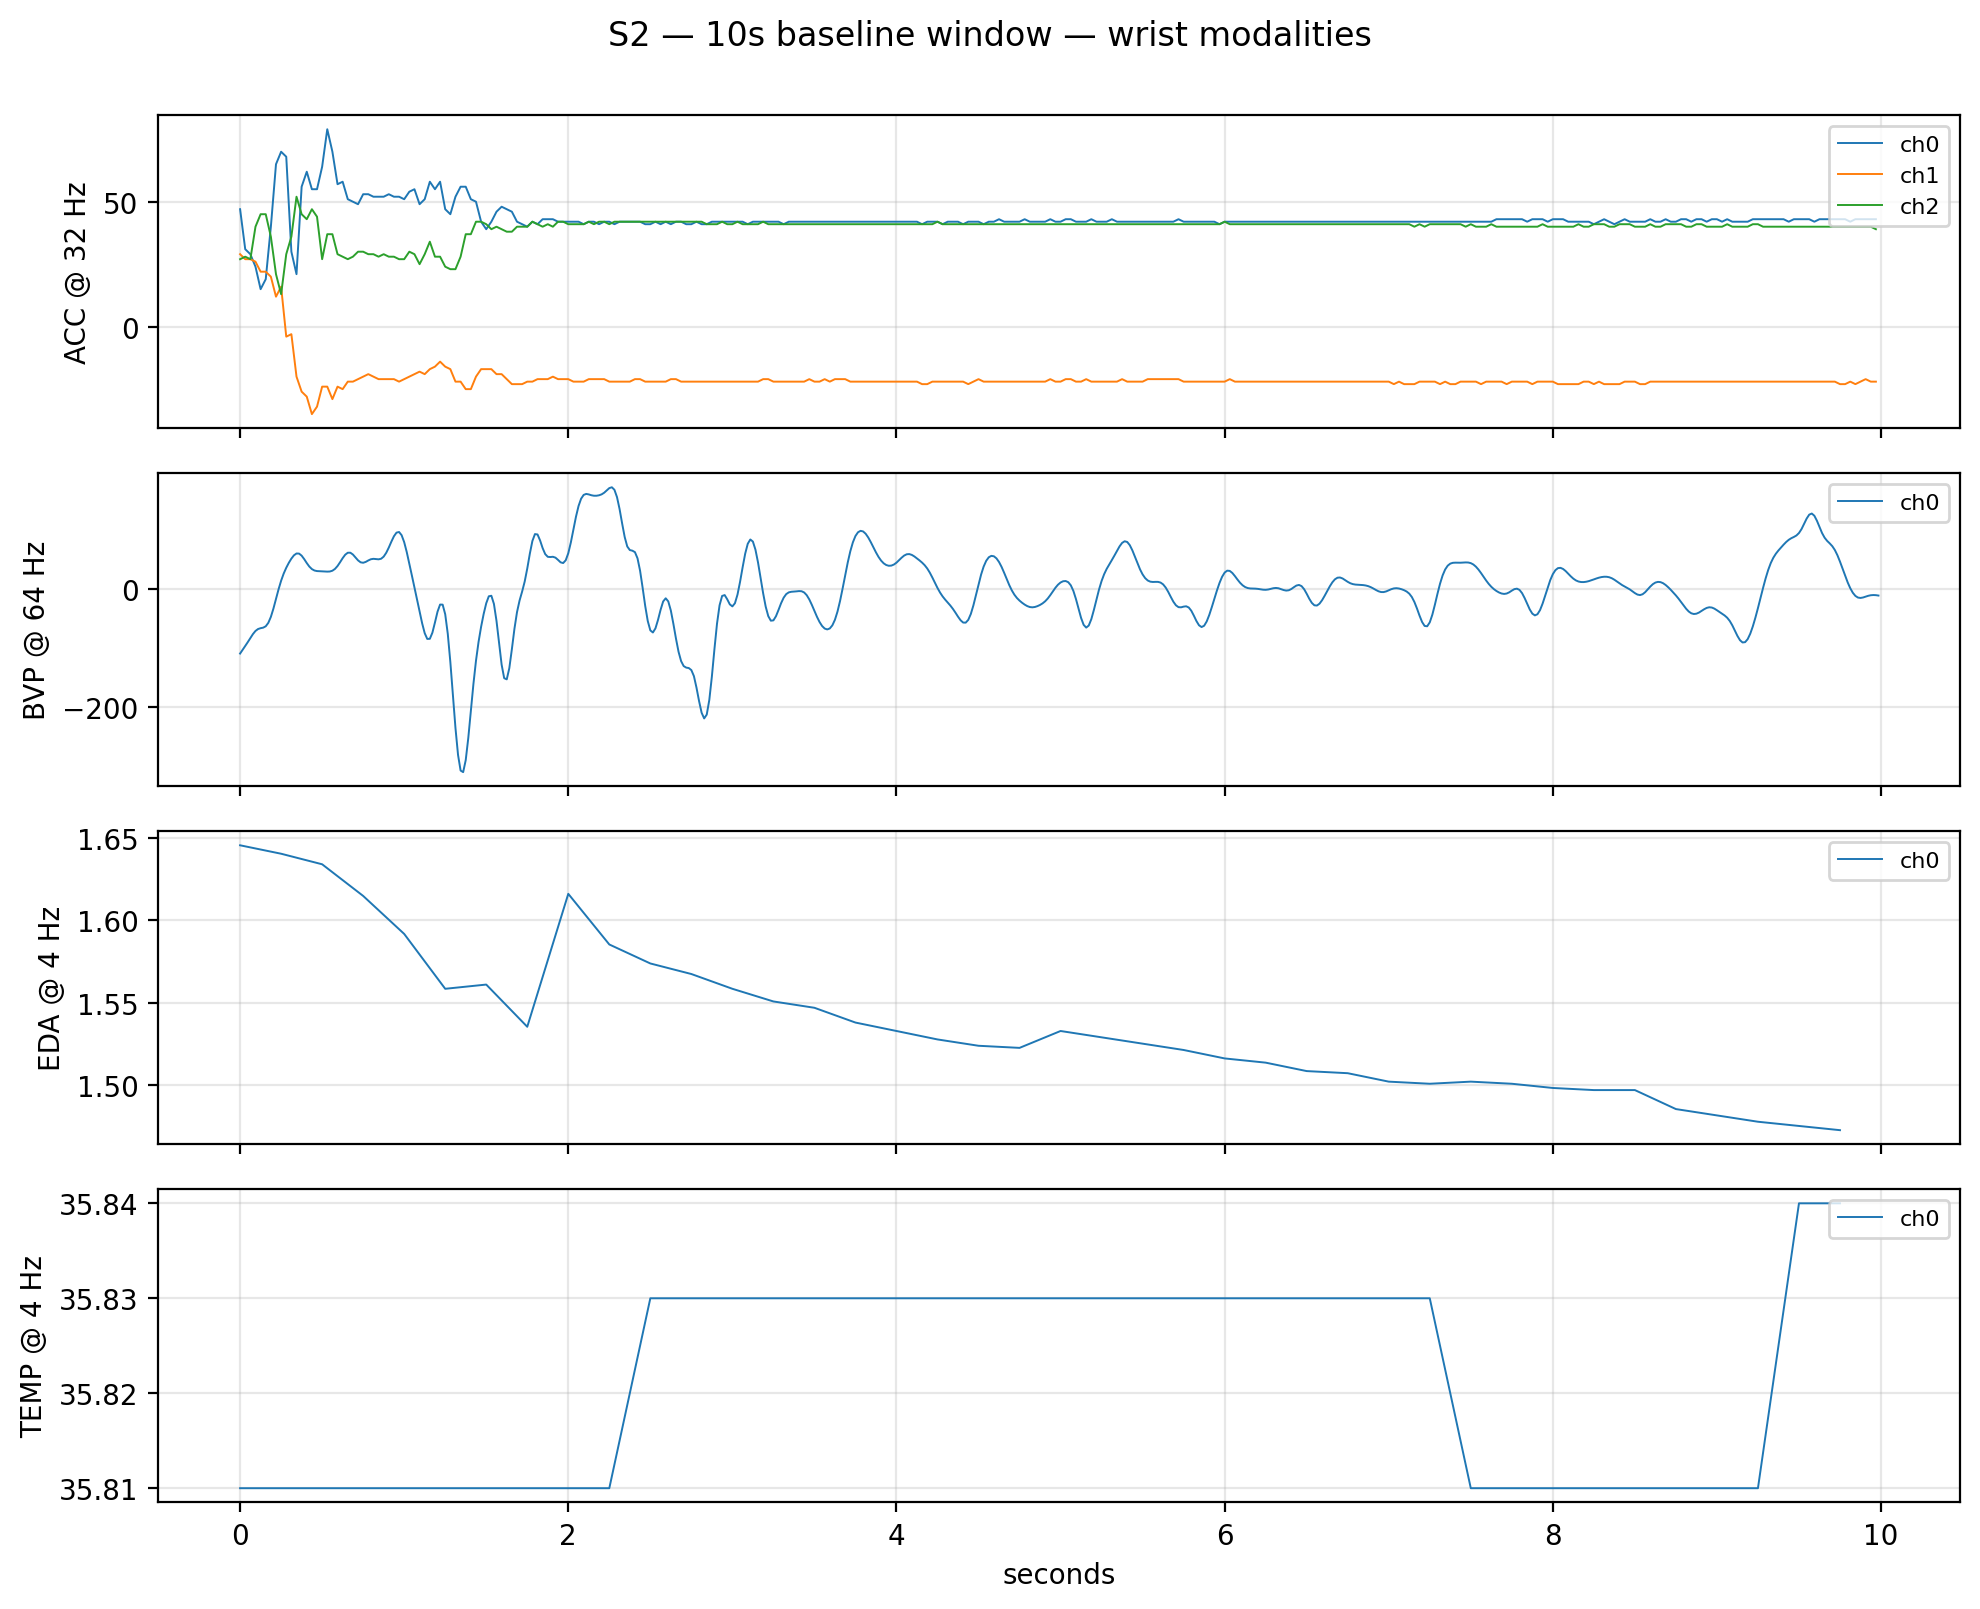

In [6]:
wrist = data["signal"]["wrist"]
start_s = start / CHEST_FS_NOMINAL  # reuse chest baseline window start

fig, axes = plt.subplots(len(wrist), 1, figsize=(10, 2 * len(wrist)), sharex=True)
for ax, (m, arr) in zip(axes, wrist.items()):
    fs = WRIST_FS_NOMINAL[m]
    s = int(start_s * fs)
    window = arr[s : s + WINDOW_S * fs]
    t = np.arange(len(window)) / fs
    if window.ndim > 1:
        for ch in range(window.shape[1]):
            ax.plot(t, window[:, ch], lw=0.7, label=f"ch{ch}")
        ax.legend(loc="upper right", fontsize=8)
    else:
        ax.plot(t, window, lw=0.7)
    ax.set_ylabel(f"{m} @ {fs} Hz")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("seconds")
fig.suptitle(f"S{SUBJECT_ID} — 10s baseline window — wrist modalities", y=1.0)
fig.tight_layout()

out_path = Path("../images/2026-05-28-s2-wrist-10s-baseline.png")
fig.savefig(out_path, dpi=110, bbox_inches="tight")
print(f"Saved: {out_path.resolve()}")
plt.show()

## 5-row previews

Compact head() of each modality. These previews and the observed min/max ranges from the summary frame above feed the empirical envelope table in [`docs/SCHEMA.md`](../docs/SCHEMA.md).


In [7]:
def preview(name, arr, n=5):
    if arr.ndim == 1:
        return pd.DataFrame({name: arr[:n]})
    return pd.DataFrame(arr[:n], columns=[f"{name}_ch{i}" for i in range(arr.shape[1])])

print("=== Chest ===")
for m, arr in data["signal"]["chest"].items():
    print(f"\n{m} {arr.shape}")
    print(preview(m, arr).to_string(index=False))

print("\n=== Wrist ===")
for m, arr in data["signal"]["wrist"].items():
    print(f"\n{m} {arr.shape}")
    print(preview(m, arr).to_string(index=False))

=== Chest ===

ACC (4255300, 3)
 ACC_ch0  ACC_ch1  ACC_ch2
  0.9554  -0.2220  -0.5580
  0.9258  -0.2216  -0.5538
  0.9082  -0.2196  -0.5392
  0.8974  -0.2102  -0.5122
  0.8882  -0.2036  -0.4824

ECG (4255300, 1)
 ECG_ch0
0.021423
0.020325
0.016525
0.016708
0.011673

EMG (4255300, 1)
  EMG_ch0
-0.004440
 0.004349
 0.005173
 0.007187
-0.015152

EDA (4255300, 1)
 EDA_ch0
5.250549
5.267334
5.243301
5.249405
5.286407

Temp (4255300, 1)
 Temp_ch0
30.120758
30.129517
30.138214
30.129517
30.130951

Resp (4255300, 1)
 Resp_ch0
-1.148987
-1.124573
-1.152039
-1.158142
-1.161194

=== Wrist ===

ACC (194528, 3)
 ACC_ch0  ACC_ch1  ACC_ch2
    62.0    -21.0    107.0
    66.0     13.0     53.0
    41.0      9.0     15.0
    52.0     16.0     24.0
    54.0     15.0     34.0

BVP (389056, 1)
 BVP_ch0
  -59.37
  -53.42
  -44.40
  -33.17
  -20.79

EDA (24316, 1)
 EDA_ch0
1.138257
1.125444
1.011405
1.033188
0.935807

TEMP (24316, 1)
 TEMP_ch0
    35.41
    35.41
    35.41
    35.41
    35.41


---

Checks confirmed for S2:

- `load_wesad()` round-trips the pickle cleanly (Python-2 encoding handled inside the loader)
- chest sampling rate is 700 Hz across all six modalities
- wrist sampling rates match nominal: ACC 32 Hz, BVP 64 Hz, EDA 4 Hz, TEMP 4 Hz
- label distribution covers the expected 5 active codes (0, 1, 2, 3, 4) plus recovery codes (6, 7)
- chest and wrist 10-second baseline plots saved to `images/`

The schema contract these checks validate lives in [`docs/SCHEMA.md`](../docs/SCHEMA.md).
